# Low-Resolution Lag Ratio Decisive Sweep

Focused test for whether low-resolution Vecchia prefers full lag-1 neighborhoods and a larger lag-2 allocation. The main sweep fixes the current-time neighbor count at A=12 and varies B/A and C/A. A matched-total control checks whether any gain from full lagged neighborhoods is just due to using more total conditioning points.


In [1]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec_band
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

# Low-resolution stress test: same domain, 4x coarser in both lat/lon.
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 4
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)


DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.176 0.252


## Settings And Model Groups


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 30
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2
NO_LAG2_DAILY_STRIDE = T_STEPS + 1

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

def total_conditioning(a, b=0, c=0, uses_lag1=True, uses_lag2=True, n_advec=0):
    total = int(a)
    if uses_lag1:
        total += int(1 + b + n_advec)
    if uses_lag2:
        total += int(1 + c)
    return total

def std_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE, uses_lag2=True):
    return {
        "name": name,
        "group": group,
        "kernel": "std",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": int(daily_stride),
        "uses_lag2": bool(uses_lag2),
        "neighbor_budget": int(a + b + c),
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if (a and uses_lag2) else 0.0,
        "total_conditioning": total_conditioning(a, b, c, uses_lag1=True, uses_lag2=uses_lag2),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b}; t-2: same loc + {c}",
    }

EXPERIMENT_GROUPS = {
    # Main decisive sweep: keep current spatial information fixed and ask whether
    # full lag-1 and/or lag-2 around 0.75x is genuinely better.
    "fixed_A12_lag_ratio": [
        std_spec("A12_B09_C06_B075_C050", 12, 9, 6, "fixed_A12_lag_ratio", "B=0.75x, C=0.50x"),
        std_spec("A12_B10_C06_B083_C050", 12, 10, 6, "fixed_A12_lag_ratio", "B=0.83x, C=0.50x"),
        std_spec("A12_B12_C06_B100_C050", 12, 12, 6, "fixed_A12_lag_ratio", "B=1.00x, C=0.50x"),
        std_spec("A12_B09_C09_B075_C075", 12, 9, 9, "fixed_A12_lag_ratio", "B=0.75x, C=0.75x"),
        std_spec("A12_B10_C09_B083_C075", 12, 10, 9, "fixed_A12_lag_ratio", "B=0.83x, C=0.75x"),
        std_spec("A12_B12_C09_B100_C075", 12, 12, 9, "fixed_A12_lag_ratio", "B=1.00x, C=0.75x"),
    ],
    # Matched-total controls for the strongest lagged model above.
    # Full lagged model total_conditioning = 12 + (1+12) + (1+9) = 35.
    "matched_total35": [
        std_spec("FullLag_A12_B12_C09_total35", 12, 12, 9, "matched_total35", "full lag-1, lag-2 0.75x"),
        std_spec("RatioCurrent_A14_B11_C08_total35", 14, 11, 8, "matched_total35", "more current, B~0.8x, C~0.57x; matched total"),
        std_spec("RatioCurrent_A15_B11_C07_total35", 15, 11, 7, "matched_total35", "more current, B~0.73x, C~0.47x; matched total"),
    ],
}

ACTIVE_GROUPS = ["fixed_A12_lag_ratio", "matched_total35"]

MODEL_SPECS = {}
for group_name in ACTIVE_GROUPS:
    for spec in EXPERIMENT_GROUPS[group_name]:
        key = f"{group_name}::{spec['name']}"
        MODEL_SPECS[key] = spec

spec_df = pd.DataFrame(MODEL_SPECS).T
print("Active groups:", ACTIVE_GROUPS)
print("Number of model fits per MC iteration:", len(MODEL_SPECS))
display(spec_df[["group", "kernel", "limit_A", "limit_B", "limit_C", "neighbor_budget", "daily_stride", "uses_lag2", "allocation", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "description"]])



Active groups: ['fixed_A12_lag_ratio', 'matched_total35']
Number of model fits per MC iteration: 9


,group,kernel,limit_A,limit_B,limit_C,neighbor_budget,daily_stride,uses_lag2,allocation,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,description
fixed_A12_lag_ratio::A12_B09_C06_B075_C050,fixed_A12_lag_ratio,std,12,9,6,27,2,True,"B=0.75x, C=0.50x",0.75,0.5,29,t: 12; t-1: same loc + 9; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B10_C06_B083_C050,fixed_A12_lag_ratio,std,12,10,6,28,2,True,"B=0.83x, C=0.50x",0.833333,0.5,30,t: 12; t-1: same loc + 10; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B12_C06_B100_C050,fixed_A12_lag_ratio,std,12,12,6,30,2,True,"B=1.00x, C=0.50x",1.0,0.5,32,t: 12; t-1: same loc + 12; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B09_C09_B075_C075,fixed_A12_lag_ratio,std,12,9,9,30,2,True,"B=0.75x, C=0.75x",0.75,0.75,32,t: 12; t-1: same loc + 9; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B10_C09_B083_C075,fixed_A12_lag_ratio,std,12,10,9,31,2,True,"B=0.83x, C=0.75x",0.833333,0.75,33,t: 12; t-1: same loc + 10; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B12_C09_B100_C075,fixed_A12_lag_ratio,std,12,12,9,33,2,True,"B=1.00x, C=0.75x",1.0,0.75,35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::FullLag_A12_B12_C09_total35,matched_total35,std,12,12,9,33,2,True,"full lag-1, lag-2 0.75x",1.0,0.75,35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::RatioCurrent_A14_B11_C08_total35,matched_total35,std,14,11,8,33,2,True,"more current, B~0.8x, C~0.57x; matched total",0.785714,0.571429,35,t: 14; t-1: same loc + 11; t-2: same loc + 8
matched_total35::RatioCurrent_A15_B11_C07_total35,matched_total35,std,15,11,7,33,2,True,"more current, B~0.73x, C~0.47x; matched total",0.733333,0.466667,35,t: 15; t-1: same loc + 11; t-2: same loc + 7


## Simulation Helpers


In [3]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers


In [4]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, TRUE_DICT, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, TRUE_DICT, P_LABELS),
            "advec": relative_se_summary(se_by_key, TRUE_DICT, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(TRUE_DICT["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Monte Carlo


In [5]:
def fit_vecchia_spec(model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    daily_stride = int(spec.get("daily_stride", DAILY_STRIDE))
    if spec["kernel"] == "std":
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
        )
    elif spec["kernel"] == "advec_band":
        model = kernels_vecchia_advec_band.fit_vecchia_lbfgs_advec_band(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            lon_resolution=spec.get("lon_resolution", DELTA_LON),
            advec_cell_offsets=spec.get("advec_cell_offsets", (2, 3)),
        )
    else:
        raise ValueError(f"Unknown kernel: {spec['kernel']}")

    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, TRUE_DICT)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]])
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe

def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, compute_godambe=False, save_csv=True, csv_name=None):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[["group", "kernel", "limit_A", "limit_B", "limit_C", "daily_stride", "uses_lag2", "allocation", "total_conditioning", "description"]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}
        for model_key, spec in MODEL_SPECS.items():
            try:
                print(f"{model_key}: fitting", end="")
                out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                    model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=compute_godambe
                )
                est = metrics.pop("est")
                row = {
                    "iter": it + 1,
                    "model_key": model_key,
                    "model": spec["name"],
                    "group": spec["group"],
                    "kernel": spec["kernel"],
                    "allocation": spec["allocation"],
                    "limit_A": spec["limit_A"],
                    "limit_B": spec["limit_B"],
                    "limit_C": spec["limit_C"],
                    "daily_stride": spec.get("daily_stride", DAILY_STRIDE),
                    "uses_lag2": spec.get("uses_lag2", True),
                    "advec_cell_offsets": ",".join(map(str, spec.get("advec_cell_offsets", ()))),
                    "lag1_ratio_actual": spec["lag1_ratio_actual"],
                    "lag2_ratio_actual": spec["lag2_ratio_actual"],
                    "total_conditioning": spec["total_conditioning"],
                    "loss": round(loss, 6),
                    "overall_rmsre": round(metrics["overall_rmsre"], 6),
                    "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                    "range_time_re": round(metrics["range_time_re"], 6),
                    "advec_rmsre": round(metrics["advec_rmsre"], 6),
                    "nugget_re": round(metrics["nugget_re"], 6),
                    "precompute_s": round(pre_s, 3),
                    "fit_s": round(fit_s, 3),
                    "gim_s": round(gim_s, 3),
                    "total_s": round(pre_s + fit_s + gim_s, 3),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                row.update(godambe)
                records.append(row)
                print(f" | loss={loss:.4f} spatial={metrics['spatial_rmsre']:.4f} overall={metrics['overall_rmsre']:.4f} time={pre_s + fit_s + gim_s:.1f}s")
            except Exception as exc:
                print(f" | FAILED: {type(exc).__name__}: {exc}")
                records.append({"iter": it + 1, "model_key": model_key, "model": spec.get("name", model_key), "group": spec.get("group"), "error": repr(exc)})
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_x4_all_tests_results.csv"
        out_path = out_dir / csv_name
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df


## Optional One-Shot Godambe


In [6]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lowres_x4_lag_ratio_decisive_godambe_043026_results.csv",
    )
    display(df_godambe.sort_values(["group", "gim_spatial_rel_se"]))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it.")




Grid: 29 x 40 x 8 = 9,280 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.25199999999998113, 'lon_max_step': 0.25200000000000955, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.828)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
fixed_A12_lag_ratio::A12_B09_C06_B075_C050,fixed_A12_lag_ratio,std,12,9,6,2,True,"B=0.75x, C=0.50x",29,t: 12; t-1: same loc + 9; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B10_C06_B083_C050,fixed_A12_lag_ratio,std,12,10,6,2,True,"B=0.83x, C=0.50x",30,t: 12; t-1: same loc + 10; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B12_C06_B100_C050,fixed_A12_lag_ratio,std,12,12,6,2,True,"B=1.00x, C=0.50x",32,t: 12; t-1: same loc + 12; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B09_C09_B075_C075,fixed_A12_lag_ratio,std,12,9,9,2,True,"B=0.75x, C=0.75x",32,t: 12; t-1: same loc + 9; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B10_C09_B083_C075,fixed_A12_lag_ratio,std,12,10,9,2,True,"B=0.83x, C=0.75x",33,t: 12; t-1: same loc + 10; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B12_C09_B100_C075,fixed_A12_lag_ratio,std,12,12,9,2,True,"B=1.00x, C=0.75x",35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::FullLag_A12_B12_C09_total35,matched_total35,std,12,12,9,2,True,"full lag-1, lag-2 0.75x",35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::RatioCurrent_A14_B11_C08_total35,matched_total35,std,14,11,8,2,True,"more current, B~0.8x, C~0.57x; matched total",35,t: 14; t-1: same loc + 11; t-2: same loc + 8
matched_total35::RatioCurrent_A15_B11_C07_total35,matched_total35,std,15,11,7,2,True,"more current, B~0.73x, C~0.47x; matched total",35,t: 15; t-1: same loc + 11; t-2: same loc + 7


Ordering done

=== Iteration 1/1 ===
fixed_A12_lag_ratio::A12_B09_C06_B075_C050: fitting | loss=1.5985 spatial=0.0411 overall=0.0982 time=10.9s
fixed_A12_lag_ratio::A12_B10_C06_B083_C050: fitting | loss=1.5978 spatial=0.0357 overall=0.0985 time=12.9s
fixed_A12_lag_ratio::A12_B12_C06_B100_C050: fitting | loss=1.5964 spatial=0.0379 overall=0.1076 time=11.2s
fixed_A12_lag_ratio::A12_B09_C09_B075_C075: fitting | loss=1.6096 spatial=0.0988 overall=0.2047 time=12.3s
fixed_A12_lag_ratio::A12_B10_C09_B083_C075: fitting | loss=1.6108 spatial=0.0789 overall=0.1870 time=14.4s
fixed_A12_lag_ratio::A12_B12_C09_B100_C075: fitting | loss=1.6115 spatial=0.0537 overall=0.1624 time=14.9s
matched_total35::FullLag_A12_B12_C09_total35: fitting | loss=1.6115 spatial=0.0537 overall=0.1624 time=14.9s
matched_total35::RatioCurrent_A14_B11_C08_total35: fitting | loss=1.5945 spatial=0.1232 overall=0.1884 time=15.6s
matched_total35::RatioCurrent_A15_B11_C07_total35: fitting | loss=1.5896 spatial=0.1538 overall=0.

,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
3,1,fixed_A12_lag_ratio::A12_B09_C09_B075_C075,A12_B09_C09_B075_C075,fixed_A12_lag_ratio,std,"B=0.75x, C=0.75x",12,9,9,2,...,0.091221,0.053993,0.053990,0.707530,0.031248,0.038175,0.252166,0.013821,0.016701,0.569736
4,1,fixed_A12_lag_ratio::A12_B10_C09_B083_C075,A12_B10_C09_B083_C075,fixed_A12_lag_ratio,std,"B=0.83x, C=0.75x",12,10,9,2,...,0.092113,0.055124,0.055121,0.674471,0.032445,0.038385,0.260644,0.012253,0.015286,0.522900
0,1,fixed_A12_lag_ratio::A12_B09_C06_B075_C050,A12_B09_C06_B075_C050,fixed_A12_lag_ratio,std,"B=0.75x, C=0.50x",12,9,6,2,...,0.096564,0.058178,0.058175,0.676501,0.034120,0.040913,0.257397,0.013043,0.015636,0.481062
5,1,fixed_A12_lag_ratio::A12_B12_C09_B100_C075,A12_B12_C09_B100_C075,fixed_A12_lag_ratio,std,"B=1.00x, C=0.75x",12,12,9,2,...,0.099290,0.057722,0.057719,0.731842,0.035305,0.040734,0.260371,0.012968,0.015675,0.529804
1,1,fixed_A12_lag_ratio::A12_B10_C06_B083_C050,A12_B10_C06_B083_C050,fixed_A12_lag_ratio,std,"B=0.83x, C=0.50x",12,10,6,2,...,0.100779,0.059341,0.059338,0.690521,0.035831,0.042775,0.275636,0.012007,0.014514,0.472604
2,1,fixed_A12_lag_ratio::A12_B12_C06_B100_C050,A12_B12_C06_B100_C050,fixed_A12_lag_ratio,std,"B=1.00x, C=0.50x",12,12,6,2,...,0.111562,0.063346,0.063342,0.754076,0.040138,0.046906,0.300192,0.012174,0.015061,0.484352
8,1,matched_total35::RatioCurrent_A15_B11_C07_total35,RatioCurrent_A15_B11_C07_total35,matched_total35,std,"more current, B~0.73x, C~0.47x; matched total",15,11,7,2,...,0.074746,0.046691,0.046689,0.659435,0.024327,0.030560,0.187126,0.011341,0.013615,0.497119
7,1,matched_total35::RatioCurrent_A14_B11_C08_total35,RatioCurrent_A14_B11_C08_total35,matched_total35,std,"more current, B~0.8x, C~0.57x; matched total",14,11,8,2,...,0.081520,0.051572,0.051569,0.640283,0.027459,0.034547,0.206023,0.013044,0.016676,0.493915
6,1,matched_total35::FullLag_A12_B12_C09_total35,FullLag_A12_B12_C09_total35,matched_total35,std,"full lag-1, lag-2 0.75x",12,12,9,2,...,0.099290,0.057722,0.057719,0.731842,0.035305,0.040734,0.260371,0.012968,0.015675,0.529804


## Monte Carlo Sweep


In [7]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lowres_x4_lag_ratio_decisive_mc_043026_results.csv",
)
df_mc.head()




Grid: 29 x 40 x 8 = 9,280 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.25199999999998113, 'lon_max_step': 0.25200000000000955, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.828)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
fixed_A12_lag_ratio::A12_B09_C06_B075_C050,fixed_A12_lag_ratio,std,12,9,6,2,True,"B=0.75x, C=0.50x",29,t: 12; t-1: same loc + 9; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B10_C06_B083_C050,fixed_A12_lag_ratio,std,12,10,6,2,True,"B=0.83x, C=0.50x",30,t: 12; t-1: same loc + 10; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B12_C06_B100_C050,fixed_A12_lag_ratio,std,12,12,6,2,True,"B=1.00x, C=0.50x",32,t: 12; t-1: same loc + 12; t-2: same loc + 6
fixed_A12_lag_ratio::A12_B09_C09_B075_C075,fixed_A12_lag_ratio,std,12,9,9,2,True,"B=0.75x, C=0.75x",32,t: 12; t-1: same loc + 9; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B10_C09_B083_C075,fixed_A12_lag_ratio,std,12,10,9,2,True,"B=0.83x, C=0.75x",33,t: 12; t-1: same loc + 10; t-2: same loc + 9
fixed_A12_lag_ratio::A12_B12_C09_B100_C075,fixed_A12_lag_ratio,std,12,12,9,2,True,"B=1.00x, C=0.75x",35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::FullLag_A12_B12_C09_total35,matched_total35,std,12,12,9,2,True,"full lag-1, lag-2 0.75x",35,t: 12; t-1: same loc + 12; t-2: same loc + 9
matched_total35::RatioCurrent_A14_B11_C08_total35,matched_total35,std,14,11,8,2,True,"more current, B~0.8x, C~0.57x; matched total",35,t: 14; t-1: same loc + 11; t-2: same loc + 8
matched_total35::RatioCurrent_A15_B11_C07_total35,matched_total35,std,15,11,7,2,True,"more current, B~0.73x, C~0.47x; matched total",35,t: 15; t-1: same loc + 11; t-2: same loc + 7


Ordering done

=== Iteration 1/30 ===
fixed_A12_lag_ratio::A12_B09_C06_B075_C050: fitting | loss=1.5985 spatial=0.0411 overall=0.0982 time=7.6s
fixed_A12_lag_ratio::A12_B10_C06_B083_C050: fitting | loss=1.5978 spatial=0.0357 overall=0.0985 time=8.8s
fixed_A12_lag_ratio::A12_B12_C06_B100_C050: fitting | loss=1.5964 spatial=0.0379 overall=0.1076 time=7.2s
fixed_A12_lag_ratio::A12_B09_C09_B075_C075: fitting | loss=1.6096 spatial=0.0988 overall=0.2047 time=8.5s
fixed_A12_lag_ratio::A12_B10_C09_B083_C075: fitting | loss=1.6108 spatial=0.0789 overall=0.1870 time=10.6s
fixed_A12_lag_ratio::A12_B12_C09_B100_C075: fitting | loss=1.6115 spatial=0.0537 overall=0.1624 time=12.0s
matched_total35::FullLag_A12_B12_C09_total35: fitting | loss=1.6115 spatial=0.0537 overall=0.1624 time=11.2s
matched_total35::RatioCurrent_A14_B11_C08_total35: fitting | loss=1.5945 spatial=0.1232 overall=0.1884 time=10.9s
matched_total35::RatioCurrent_A15_B11_C07_total35: fitting | loss=1.5896 spatial=0.1538 overall=0.225

,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_s,total_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,fixed_A12_lag_ratio::A12_B09_C06_B075_C050,A12_B09_C06_B075_C050,fixed_A12_lag_ratio,std,"B=0.75x, C=0.50x",12,9,6,2,...,0.0,7.618,4,10.109878,0.298482,0.371970,1.935514,0.090365,-0.146448,2.161421
1,1,fixed_A12_lag_ratio::A12_B10_C06_B083_C050,A12_B10_C06_B083_C050,fixed_A12_lag_ratio,std,"B=0.83x, C=0.50x",12,10,6,2,...,0.0,8.835,4,10.161160,0.306512,0.377788,2.063817,0.094075,-0.144868,2.252892
2,1,fixed_A12_lag_ratio::A12_B12_C06_B100_C050,A12_B12_C06_B100_C050,fixed_A12_lag_ratio,std,"B=1.00x, C=0.50x",12,12,6,2,...,0.0,7.202,4,10.036057,0.319633,0.398619,2.111258,0.092323,-0.154086,2.459364
3,1,fixed_A12_lag_ratio::A12_B09_C09_B075_C075,A12_B09_C09_B075_C075,fixed_A12_lag_ratio,std,"B=0.75x, C=0.75x",12,9,9,2,...,0.0,8.530,1,10.081917,0.272424,0.342374,1.848356,0.116480,-0.131559,1.949528
4,1,fixed_A12_lag_ratio::A12_B10_C09_B083_C075,A12_B10_C09_B083_C075,fixed_A12_lag_ratio,std,"B=0.83x, C=0.75x",12,10,9,2,...,0.0,10.625,1,9.980123,0.282431,0.350615,1.964418,0.116568,-0.126174,2.174780


In [8]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

def summarize_mc(df):
    metric_cols = ["loss", "overall_rmsre", "spatial_rmsre", "range_time_re", "advec_rmsre", "nugget_re", "total_s"]
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        row = {
            "group": group,
            "model": model,
            "kernel": sub["kernel"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "daily_stride": int(sub["daily_stride"].iloc[0]),
            "uses_lag2": bool(sub["uses_lag2"].iloc[0]),
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)

def parameter_re_summary(df):
    true = {
        "sigmasq": TRUE_DICT["sigmasq"],
        "range_lat": TRUE_DICT["range_lat"],
        "range_lon": TRUE_DICT["range_lon"],
        "range_time": TRUE_DICT["range_time"],
        "advec_lat": TRUE_DICT["advec_lat"],
        "advec_lon": TRUE_DICT["advec_lon"],
        "nugget": TRUE_DICT["nugget"],
    }
    est_cols = {
        "sigmasq": "sigmasq_est",
        "range_lat": "range_lat_est",
        "range_lon": "range_lon_est",
        "range_time": "range_t_est",
        "advec_lat": "advec_lat_est",
        "advec_lon": "advec_lon_est",
        "nugget": "nugget_est",
    }
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        for par, col in est_cols.items():
            tv = true[par]
            vals = (sub[col] - tv).abs() / abs(tv) if abs(tv) >= 0.01 else (sub[col] - tv).abs()
            rows.append({
                "group": group,
                "model": model,
                "parameter": par,
                "mean_re": vals.mean(),
                "median_re": vals.median(),
                "p90_p10_re": p90_p10(vals.to_numpy()),
            })
    return pd.DataFrame(rows)

mc_summary = summarize_mc(df_mc)
param_summary = parameter_re_summary(df_mc)
display(mc_summary.sort_values(["group", "overall_rmsre_mean"]))
display(param_summary.sort_values(["group", "parameter", "mean_re"]))


,group,model,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,uses_lag2,total_conditioning,...,range_time_re_p90_p10,advec_rmsre_mean,advec_rmsre_median,advec_rmsre_p90_p10,nugget_re_mean,nugget_re_median,nugget_re_p90_p10,total_s_mean,total_s_median,total_s_p90_p10
0,fixed_A12_lag_ratio,A12_B09_C06_B075_C050,std,"B=0.75x, C=0.50x",12,9,6,2,True,29,...,0.172233,0.124730,0.125217,0.159499,0.169196,0.143898,0.282266,7.124200,7.5570,2.9600
1,fixed_A12_lag_ratio,A12_B10_C06_B083_C050,std,"B=0.83x, C=0.50x",12,10,6,2,True,30,...,0.181739,0.122600,0.113734,0.154853,0.181771,0.119094,0.285337,7.224100,6.9975,2.8680
2,fixed_A12_lag_ratio,A12_B12_C06_B100_C050,std,"B=1.00x, C=0.50x",12,12,6,2,True,32,...,0.181302,0.123712,0.110529,0.126317,0.191728,0.159273,0.354512,7.793300,7.9405,2.3053
5,fixed_A12_lag_ratio,A12_B12_C09_B100_C075,std,"B=1.00x, C=0.75x",12,12,9,2,True,35,...,0.173866,0.122466,0.124680,0.159669,0.183805,0.113412,0.409927,9.766400,9.6720,2.6338
3,fixed_A12_lag_ratio,A12_B09_C09_B075_C075,std,"B=0.75x, C=0.75x",12,9,9,2,True,32,...,0.180186,0.119089,0.095412,0.225536,0.196903,0.173765,0.366677,7.716933,7.6120,1.9083
4,fixed_A12_lag_ratio,A12_B10_C09_B083_C075,std,"B=0.83x, C=0.75x",12,10,9,2,True,33,...,0.190603,0.126149,0.112541,0.167493,0.189966,0.159718,0.341397,9.337367,9.2585,2.6561
6,matched_total35,FullLag_A12_B12_C09_total35,std,"full lag-1, lag-2 0.75x",12,12,9,2,True,35,...,0.173866,0.122466,0.124680,0.159669,0.183805,0.113412,0.409927,9.749667,9.7200,2.7081
7,matched_total35,RatioCurrent_A14_B11_C08_total35,std,"more current, B~0.8x, C~0.57x; matched total",14,11,8,2,True,35,...,0.171540,0.129048,0.123846,0.175450,0.189441,0.137972,0.334708,9.837933,9.8075,3.1945
8,matched_total35,RatioCurrent_A15_B11_C07_total35,std,"more current, B~0.73x, C~0.47x; matched total",15,11,7,2,True,35,...,0.234547,0.141624,0.118300,0.185080,0.195328,0.190024,0.309434,9.514433,9.4795,3.2878


,group,model,parameter,mean_re,median_re,p90_p10_re
11,fixed_A12_lag_ratio,A12_B10_C06_B083_C050,advec_lat,0.113327,0.101475,0.213833
4,fixed_A12_lag_ratio,A12_B09_C06_B075_C050,advec_lat,0.115585,0.102569,0.189658
32,fixed_A12_lag_ratio,A12_B10_C09_B083_C075,advec_lat,0.116091,0.088763,0.241973
18,fixed_A12_lag_ratio,A12_B12_C06_B100_C050,advec_lat,0.117389,0.108250,0.220186
25,fixed_A12_lag_ratio,A12_B09_C09_B075_C075,advec_lat,0.118192,0.065431,0.255316
...,...,...,...,...,...,...
52,matched_total35,RatioCurrent_A14_B11_C08_total35,range_time,0.118192,0.124340,0.171540
59,matched_total35,RatioCurrent_A15_B11_C07_total35,range_time,0.120887,0.110434,0.234547
42,matched_total35,FullLag_A12_B12_C09_total35,sigmasq,0.057512,0.053476,0.093076
49,matched_total35,RatioCurrent_A14_B11_C08_total35,sigmasq,0.064017,0.051367,0.106848


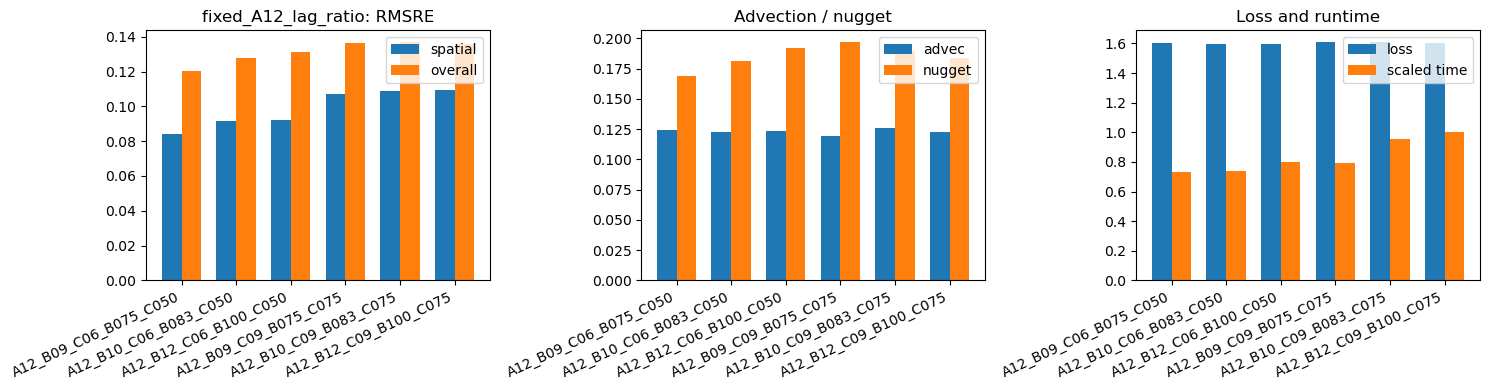

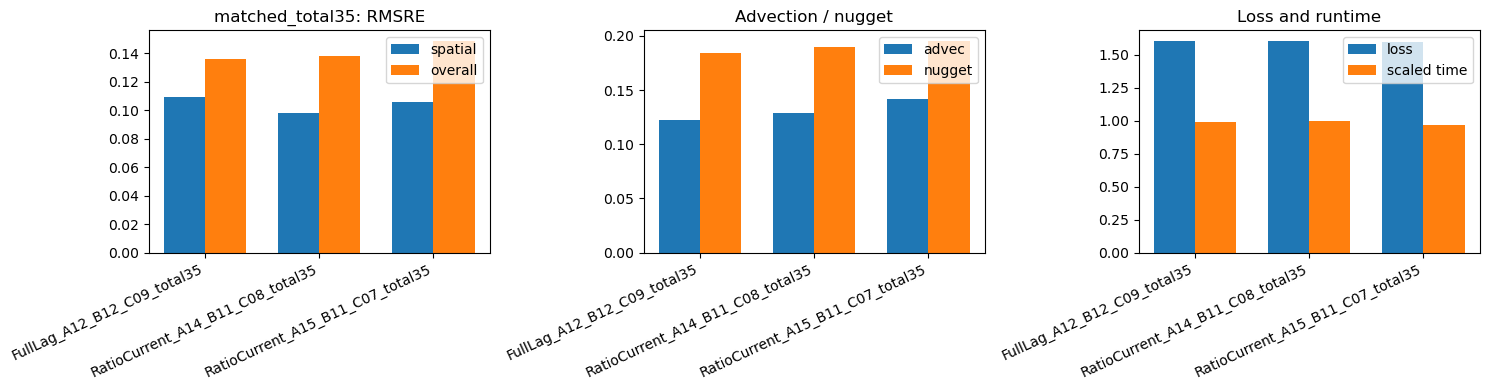

In [9]:
for group, sub in mc_summary.groupby("group", sort=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(sub))
    labels = sub["model"].to_list()

    axes[0].bar(x - 0.18, sub["spatial_rmsre_mean"], width=0.36, label="spatial")
    axes[0].bar(x + 0.18, sub["overall_rmsre_mean"], width=0.36, label="overall")
    axes[0].set_title(f"{group}: RMSRE")
    axes[0].set_xticks(x, labels, rotation=25, ha="right")
    axes[0].legend()

    axes[1].bar(x - 0.18, sub["advec_rmsre_mean"], width=0.36, label="advec")
    axes[1].bar(x + 0.18, sub["nugget_re_mean"], width=0.36, label="nugget")
    axes[1].set_title("Advection / nugget")
    axes[1].set_xticks(x, labels, rotation=25, ha="right")
    axes[1].legend()

    axes[2].bar(x - 0.18, sub["loss_mean"], width=0.36, label="loss")
    axes[2].bar(x + 0.18, sub["total_s_mean"] / max(sub["total_s_mean"].max(), 1), width=0.36, label="scaled time")
    axes[2].set_title("Loss and runtime")
    axes[2].set_xticks(x, labels, rotation=25, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## Focused Question


In [10]:
print("Question 1: with A fixed at 12, does B=1.0 and/or C=0.75 beat B=0.75/0.83 and C=0.5?")
print("Question 2: if A12/B12/C9 wins, does it still win against matched-total current-heavy alternatives?")
display(spec_df[["limit_A", "limit_B", "limit_C", "neighbor_budget", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "allocation"]])


Question 1: with A fixed at 12, does B=1.0 and/or C=0.75 beat B=0.75/0.83 and C=0.5?
Question 2: if A12/B12/C9 wins, does it still win against matched-total current-heavy alternatives?


,limit_A,limit_B,limit_C,neighbor_budget,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,allocation
fixed_A12_lag_ratio::A12_B09_C06_B075_C050,12,9,6,27,0.75,0.5,29,"B=0.75x, C=0.50x"
fixed_A12_lag_ratio::A12_B10_C06_B083_C050,12,10,6,28,0.833333,0.5,30,"B=0.83x, C=0.50x"
fixed_A12_lag_ratio::A12_B12_C06_B100_C050,12,12,6,30,1.0,0.5,32,"B=1.00x, C=0.50x"
fixed_A12_lag_ratio::A12_B09_C09_B075_C075,12,9,9,30,0.75,0.75,32,"B=0.75x, C=0.75x"
fixed_A12_lag_ratio::A12_B10_C09_B083_C075,12,10,9,31,0.833333,0.75,33,"B=0.83x, C=0.75x"
fixed_A12_lag_ratio::A12_B12_C09_B100_C075,12,12,9,33,1.0,0.75,35,"B=1.00x, C=0.75x"
matched_total35::FullLag_A12_B12_C09_total35,12,12,9,33,1.0,0.75,35,"full lag-1, lag-2 0.75x"
matched_total35::RatioCurrent_A14_B11_C08_total35,14,11,8,33,0.785714,0.571429,35,"more current, B~0.8x, C~0.57x; matched total"
matched_total35::RatioCurrent_A15_B11_C07_total35,15,11,7,33,0.733333,0.466667,35,"more current, B~0.73x, C~0.47x; matched total"


## Interpretation

If A12/B12/C9 wins in the fixed-A sweep and also wins the matched-total group, then low-resolution data genuinely prefer full lag-1 and high lag-2 allocation. If it wins only in fixed-A but not under matched total, the gain mostly comes from using more total conditioning points. If A12/B10/C6 or A12/B12/C6 is competitive, then C=0.5 is enough and lag-2=0.75 is unnecessary.
